In [1]:
import os
from glob import glob
from skimage.io import imread
from enum import StrEnum, auto

import numpy as np
import torch
from torch.utils.data import Dataset
from torchvision.transforms import v2
from torchvision.tv_tensors import Image

from segmentation_utils import scale_intensities


class NormalizationStrategy(StrEnum):
    PER_IMAGE = auto(),
    PER_PLANE = auto(),

class ImageToImageDataset(Dataset):

    def __init__(
        self,
        base_path,
        input_subfolder,
        output_subfolder,
        transforms=None,
        normalization_strategy: NormalizationStrategy = None,
        normalization_quantiles=(0.0, 1.0)
    ):
        """
        PyTorch Dataset of two matched TIF stacks for image-to-image models.
        
        Parameters
        ----------
        base_path: str
            path of the dataset
        input_subfolder: str
            subfolder containing input images in TIF format
        output_subfolder: str
            subfolder containing output images in TIF format
        transforms: torchvision v2 transform
            transforms to be applied to images. should only be for augmentation
            conversion to tensor is done already
        """

        self.images_in = []
        self.images_out = []
        self.transforms = transforms

        # NOTE: we assume matched image pairs in same lexicographical order
        in_files = sorted(glob(os.path.join(base_path, input_subfolder, "*.tif")))
        out_files = sorted(glob(os.path.join(base_path, output_subfolder, "*.tif")))

        for in_file, out_file in zip(in_files, out_files):

            img_in = imread(in_file)
            img_out = imread(out_file)

            # add dummy z axis for 2D data
            if img_in.ndim == 2:
                img_in = img_in[np.newaxis]
                img_out = img_out[np.newaxis]

            # normalize intensities (or not)
            # NOTE: do it before conversion to torch as torch.quantile seems to struggle with large arrays
            img_in = ImageToImageDataset._normalize_intensities(img_in, normalization_strategy, normalization_quantiles)
            img_out = ImageToImageDataset._normalize_intensities(img_out, normalization_strategy, normalization_quantiles)

            # to torch tensors with standard datatypes
            img_in = torch.from_numpy(img_in).float()
            img_out = torch.from_numpy(img_out).float()

            # add image planes to input, output
            self.images_in.extend(img_in)
            self.images_out.extend(img_out)

        # convert to torchvision TVTensors (so augmentations can be easily applied to both imgs)
        self.images_in = [Image(img_in) for img_in in self.images_in]
        self.images_out = [Image(img_out) for img_out in self.images_out]

    @staticmethod
    def _normalize_intensities(img, normalization_strategy=None, normalization_quantiles= (0.0, 1.0)):
        
        if normalization_strategy is None:
            return img
        
        elif normalization_strategy == NormalizationStrategy.PER_IMAGE:
            vl, vh = np.quantile(img, normalization_quantiles)
            return scale_intensities(img.astype(np.float32), (vl, vh))
        
        elif normalization_strategy == NormalizationStrategy.PER_PLANE:
            planes = []
            for plane in img:
                vl, vh = np.quantile(plane, normalization_quantiles)
                planes.append( scale_intensities(plane.astype(np.float32), (vl, vh)) )
            return np.stack(planes)
        else:
            raise ValueError('Invalid normalization strategy')
    
    def __getitem__(self, idx):

        img_in, img_out = self.images_in[idx], self.images_out[idx]

        # apply transforms if necessary
        if self.transforms is not None:
            img_in, img_out = self.transforms(img_in, img_out)

        return img_in, img_out

    def __len__(self):
        return len(self.images_in)

In [43]:
from unet import LightningUNet
from lightning import pytorch as L
from torch.nn.functional import mse_loss, smooth_l1_loss, l1_loss

class ImageToImageUNet(LightningUNet):

    """
    Training subclass of lightning UNet for image-to-image
    """

    def training_step(self, batch, batch_idx):
        
        # apply net
        x, y = batch
        pred = self.forward(x)

        # print(y.shape)

        x_pred = pred[:,0:1].contiguous()
        y_pred = pred[:,1:2].contiguous()

        loss_autoenc = smooth_l1_loss(x_pred, x, beta=0.001)
        loss_reconstruction = smooth_l1_loss(y_pred, y, beta=0.001)

        self.log('loss_ae', loss_autoenc, prog_bar=True)
        self.log('loss_rec', loss_reconstruction, prog_bar=True)
        
        return loss_autoenc + loss_reconstruction

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

In [10]:
base_dir = '/Users/david/Desktop/jurkat_nucleolin'

# random crop and flips
tr = v2.Compose(
    [
        v2.RandomCrop((256, 256)),
        v2.RandomHorizontalFlip(),
        v2.RandomVerticalFlip()
    ]
)

dataset = ImageToImageDataset(
    base_dir,
    input_subfolder='tif_dapi',
    output_subfolder='tif',
    transforms=tr,
    normalization_strategy='per_image'
)


len(dataset)

427

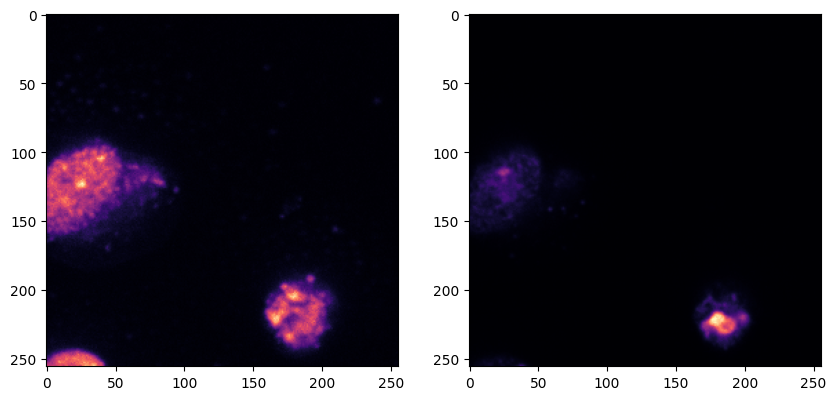

In [12]:
from matplotlib import pyplot as plt

img_in, img_out = dataset[20]

fig, axs = plt.subplots(ncols=2, figsize=(10,5))
axs[0].imshow(img_in.squeeze(), cmap='magma')
axs[1].imshow(img_out.squeeze(), cmap='magma')

In [40]:
torch.zeros((8,2,200,200))[:,1:2].shape

torch.Size([8, 1, 200, 200])

In [44]:
from torch.utils.data import DataLoader

net = ImageToImageUNet(2, [32, 64, 64, 128])
loader = DataLoader(dataset, batch_size=8, shuffle=True)

trainer = L.Trainer(
    logger=L.loggers.CSVLogger(""),
    log_every_n_steps=np.ceil(len(dataset) / loader.batch_size),
    max_epochs=300,
)

trainer.fit(net, loader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ unet │ UNet │  937 K │ train │     0 │
└───┴──────┴──────┴────────┴───────┴───────┘

Trainable params: 937 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 937 K                                                                                                
Total estimated model params size (MB): 3.751                                                                      
Modules in train mode: 64                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/Users/david/miniconda3/envs/env-py314/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/david/miniconda3/envs/env-py314/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/Users/david/miniconda3/envs/env-py314/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [45]:
from lightning.pytorch.utilities.model_summary import ModelSummary

net_inference =  LightningUNet.load_from_checkpoint('lightning_logs/version_21/checkpoints/epoch=69-step=3780.ckpt').eval()
ModelSummary(net_inference, max_depth=3)

   | Name                         | Type       | Params | Mode | FLOPs
----------------------------------------------------------------------------
0  | unet                         | UNet       | 937 K  | eval | 0    
1  | unet.encoder                 | ModuleDict | 590 K  | eval | 0    
2  | unet.encoder.encoder_block_0 | ConvBlock  | 18.8 K | eval | 0    
3  | unet.encoder.encoder_block_1 | ConvBlock  | 92.4 K | eval | 0    
4  | unet.encoder.encoder_block_2 | ConvBlock  | 110 K  | eval | 0    
5  | unet.encoder.encoder_block_3 | ConvBlock  | 369 K  | eval | 0    
6  | unet.decoder                 | ModuleDict | 332 K  | eval | 0    
7  | unet.decoder.decoder_block_0 | ConvBlock  | 147 K  | eval | 0    
8  | unet.decoder.decoder_block_1 | ConvBlock  | 147 K  | eval | 0    
9  | unet.decoder.decoder_block_2 | ConvBlock  | 37.0 K | eval | 0    
10 | unet.up_convs                | ModuleList | 14.5 K | eval | 0    
11 | unet.up_convs.0              | Conv2d     | 8.3 K  | eval | 0    


In [46]:
test_file = '/Users/david/Desktop/jurkat_nucleolin/tif_dapi/25am11-02_5_0003_ch0.tif'

img_test = imread(test_file)
img_test = ImageToImageDataset._normalize_intensities(img_test, normalization_strategy='per_image')

# add two dummy dimensions (batch size, channels)
img = torch.from_numpy(img_test).float()[:, torch.newaxis, torch.newaxis]

# ALTERNATIVE with full loader (different batch size, etc.):
# img = torch.from_numpy(imread(test_file)).float()[:, torch.newaxis]
# predict_ds = torch.utils.data.TensorDataset(img)
# predict_loader = torch.utils.data.DataLoader(predict_ds, 1)


trainer = L.Trainer(enable_checkpointing=False, logger=False)
with torch.no_grad():
    pred = trainer.predict(net_inference, img)
    pred = torch.concat(pred)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

/Users/david/miniconda3/envs/env-py314/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


torch.Size([61, 1, 1, 1024, 1024])

In [48]:
import napari

if napari.current_viewer() is not None:
    napari.current_viewer().close()

viewer = napari.Viewer()
viewer.add_image(img.squeeze())

# view predictions of a single class
viewer.add_image(pred[:,1].squeeze())


<Image layer 'Image [1]' at 0x720b55a90>